<a href="https://colab.research.google.com/github/springboardmentor2801p/CreditPathAI/blob/roshan/CreadithpathAI_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls /content/drive/MyDrive/infosys/

credit_risk_v1.db  Loan_Default.csv


In [3]:
import os
import glob

folder = "/content/drive/MyDrive/infosys/"

files_to_delete = glob.glob(folder + "*.db") + \
                  glob.glob(folder + "Loan_Default_EDA_Ready_*.csv") + \
                  glob.glob(folder + "Loan_Default_Final_Cleaned.*") + \
                  glob.glob(folder + "Loan_Default_Preprocessed.*")

for file in files_to_delete:
    os.remove(file)
    print("Deleted:", file)

print("Cleanup complete.")

Deleted: /content/drive/MyDrive/infosys/credit_risk_v1.db
Cleanup complete.


In [4]:
!ls /content/drive/MyDrive/infosys/

Loan_Default.csv


In [5]:
import pandas as pd

file_path = "/content/drive/MyDrive/infosys/Loan_Default.csv"
df_raw = pd.read_csv(file_path)

print("Raw Shape:", df_raw.shape)

Raw Shape: (148670, 34)


In [6]:
# Clean column names
df_raw.columns = df_raw.columns.str.lower().str.strip().str.replace(" ", "_")

# Separate target
y = df_raw["status"]
X = df_raw.drop("status", axis=1)

from sklearn.impute import SimpleImputer

num_cols = X.select_dtypes(include=["int64","float64"]).columns
cat_cols = X.select_dtypes(include="object").columns

# Impute
X[num_cols] = SimpleImputer(strategy="median").fit_transform(X[num_cols])
X[cat_cols] = SimpleImputer(strategy="most_frequent").fit_transform(X[cat_cols])

# Encode
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Combine back
df_processed = X.copy()
df_processed["status"] = y.values

print("After Preprocessing:", df_processed.shape)

After Preprocessing: (148670, 51)


In [7]:
import numpy as np

# 1️⃣ Repayment Capacity
df_processed["repayment_capacity"] = (
    df_processed["income"] / (df_processed["loan_amount"] + 1)
)

# 2️⃣ Loan Burden Ratio
df_processed["loan_burden_ratio"] = (
    df_processed["loan_amount"] / (df_processed["income"] + 1)
)

# 3️⃣ Financial Stress Index
df_processed["financial_stress_index"] = (
    df_processed["ltv"] * df_processed["dtir1"]
)

# 4️⃣ Log Transform
df_processed["loan_amount_log"] = np.log1p(df_processed["loan_amount"])
df_processed["income_log"] = np.log1p(df_processed["income"])

# 🔴 Drop leakage features
leak_features = [
    "interest_rate_spread",
    "rate_of_interest",
    "upfront_charges"
]

df_processed = df_processed.drop(columns=leak_features, errors="ignore")

print("Feature Engineering Completed")
print("New Shape:", df_processed.shape)

Feature Engineering Completed
New Shape: (148670, 53)


In [8]:
import sqlite3

db_path = "/content/drive/MyDrive/infosys/credit_risk_v1.db"
conn = sqlite3.connect(db_path)

df_processed.to_sql(
    "processed_loans_v1",
    conn,
    if_exists="replace",
    index=False
)

print("Database and table created successfully.")

Database and table created successfully.


In [9]:
import sqlite3
import pandas as pd

db_path = "/content/drive/MyDrive/infosys/credit_risk_v1.db"
conn = sqlite3.connect(db_path)

df_model = pd.read_sql("SELECT * FROM processed_loans_v1;", conn)

print("Loaded Shape:", df_model.shape)

Loaded Shape: (148670, 53)


In [10]:
import sqlite3

db_path = "/content/drive/MyDrive/infosys/credit_risk_v1.db"
conn = sqlite3.connect(db_path)

df_raw.to_sql(
    "raw_loans_v1",
    conn,
    if_exists="replace",
    index=False
)

print("Raw table stored successfully.")

Raw table stored successfully.


In [11]:
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")

print("Tables in DB:", cursor.fetchall())

Tables in DB: [('processed_loans_v1',), ('raw_loans_v1',)]


In [12]:
import sqlite3
import pandas as pd

db_path = "/content/drive/MyDrive/infosys/credit_risk_v1.db"
conn = sqlite3.connect(db_path)

df_model = pd.read_sql("SELECT * FROM processed_loans_v1;", conn)

print("Loaded Shape:", df_model.shape)

Loaded Shape: (148670, 53)


In [13]:
# Remove ID column (not useful for prediction)
df_model = df_model.drop(columns=["id"], errors="ignore")

print("ID column removed if present.")
print("New Shape:", df_model.shape)

ID column removed if present.
New Shape: (148670, 52)


In [14]:
print("Target Distribution:")
print(df_model["status"].value_counts())
print("\nTarget Percentage:")
print(df_model["status"].value_counts(normalize=True))

Target Distribution:
status
0    112031
1     36639
Name: count, dtype: int64

Target Percentage:
status
0    0.753555
1    0.246445
Name: proportion, dtype: float64


In [15]:
print("Shape of Dataset:")
print(df_model.shape)

print("\nInfo:")
df_model.info()

print("\nStatistical Summary:")
df_model.describe()

Shape of Dataset:
(148670, 52)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 52 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   year                               148670 non-null  float64
 1   loan_amount                        148670 non-null  float64
 2   term                               148670 non-null  float64
 3   property_value                     148670 non-null  float64
 4   income                             148670 non-null  float64
 5   credit_score                       148670 non-null  float64
 6   ltv                                148670 non-null  float64
 7   dtir1                              148670 non-null  float64
 8   loan_limit_ncf                     148670 non-null  int64  
 9   gender_Joint                       148670 non-null  int64  
 10  gender_Male                        148670 non-null  int64  
 11  g

,year,loan_amount,term,property_value,income,credit_score,ltv,dtir1,loan_limit_ncf,gender_Joint,...,region_North-East,region_central,region_south,security_type_direct,status,repayment_capacity,loan_burden_ratio,financial_stress_index,loan_amount_log,income_log
count,148670.0,1.486700e+05,148670.000000,1.486700e+05,148670.000000,148670.000000,148670.000000,148670.000000,148670.000000,148670.000000,...,148670.000000,148670.000000,148670.000000,148670.000000,148670.000000,148670.000000,1.486700e+05,148670.000000,148670.000000,148670.000000
mean,2019.0,3.311177e+05,335.143438,4.897800e+05,6883.647811,699.789103,72.989111,37.938508,0.067115,0.278462,...,0.008307,0.058499,0.430591,0.999778,0.246445,0.023179,3.034923e+03,2796.811173,12.557363,8.575688
std,0.0,1.839093e+05,58.402488,3.420221e+05,6300.067060,115.875857,37.890714,9.663417,0.250222,0.448244,...,0.090764,0.234685,0.495161,0.014897,0.430942,0.019211,3.658993e+04,1672.261585,0.574104,0.999711
min,2019.0,1.650000e+04,96.000000,8.000000e+03,0.000000,500.000000,0.967478,5.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.992539e-01,19.349564,9.711176,0.000000
25%,2019.0,1.965000e+05,360.000000,2.880000e+05,3840.000000,599.000000,63.297872,33.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.014086,3.758028e+01,2102.697842,12.188423,8.253488
50%,2019.0,2.965000e+05,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,39.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.018927,5.282953e+01,2930.298913,12.599806,8.658866
75%,2019.0,4.365000e+05,360.000000,5.980000e+05,8280.000000,800.000000,84.722222,44.000000,0.000000,1.000000,...,0.000000,0.000000,1.000000,1.000000,0.000000,0.026605,7.095270e+01,3439.534884,12.986546,9.021719
max,2019.0,3.576500e+06,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,61.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.668717,1.836500e+06,305418.750000,15.089896,13.268334


In [16]:
print("Target Counts:")
print(df_model["status"].value_counts())

print("\nTarget Percentage:")
print(df_model["status"].value_counts(normalize=True))

Target Counts:
status
0    112031
1     36639
Name: count, dtype: int64

Target Percentage:
status
0    0.753555
1    0.246445
Name: proportion, dtype: float64


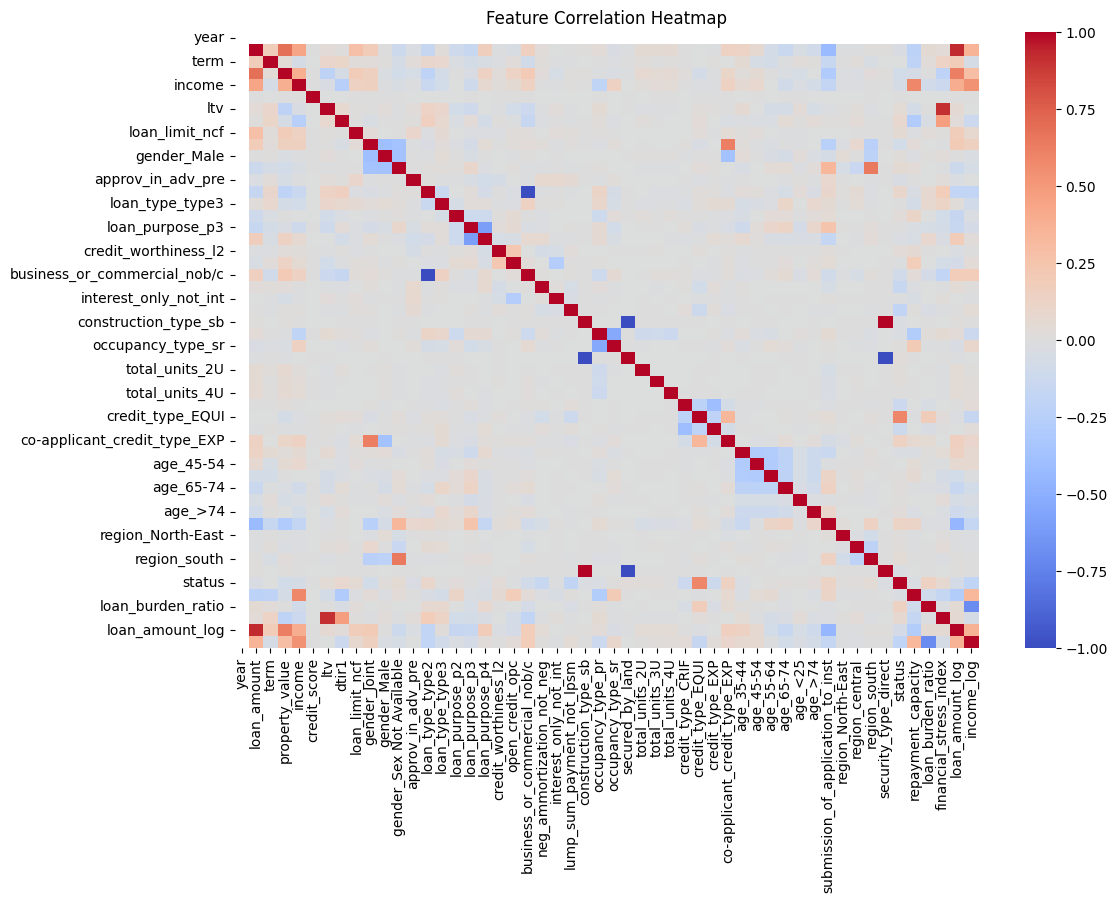

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

corr_matrix = df_model.corr()

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [18]:
corr_target = df_model.corr()["status"].abs().sort_values(ascending=False)

print("Top Features Correlated with Default:")
print(corr_target.head(10))

Top Features Correlated with Default:
status                               1.000000
credit_type_EQUI                     0.592168
income_log                           0.197088
lump_sum_payment_not_lpsm            0.187752
neg_ammortization_not_neg            0.155835
co-applicant_credit_type_EXP         0.144239
loan_burden_ratio                    0.141469
credit_type_CRIF                     0.126332
credit_type_EXP                      0.124660
submission_of_application_to_inst    0.122410
Name: status, dtype: float64


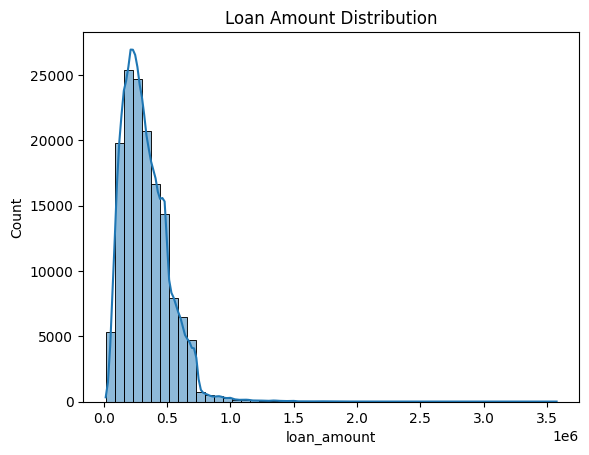

In [19]:
sns.histplot(df_model["loan_amount"], bins=50, kde=True)
plt.title("Loan Amount Distribution")
plt.show()

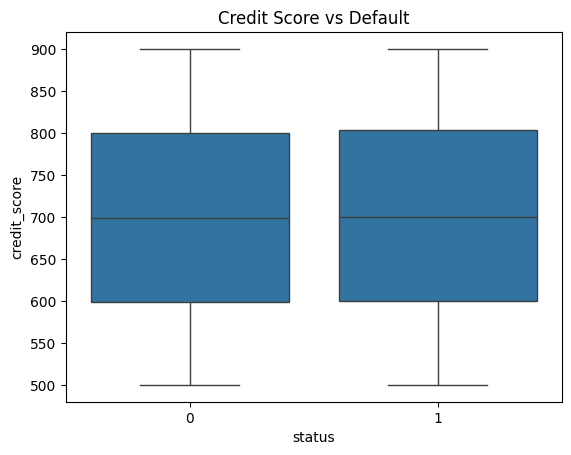

In [20]:
sns.boxplot(x="status", y="credit_score", data=df_model)
plt.title("Credit Score vs Default")
plt.show()

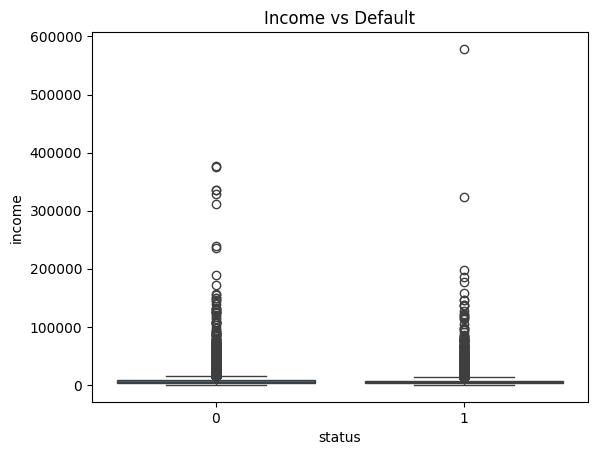

In [21]:
sns.boxplot(x="status", y="income", data=df_model)
plt.title("Income vs Default")
plt.show()

In [22]:
from sklearn.model_selection import train_test_split

X = df_model.drop("status", axis=1)
y = df_model["status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (118936, 51)
Test shape: (29734, 51)


In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=2000, class_weight="balanced")
log_model.fit(X_train_scaled, y_train)

print("Logistic Test AUC:", roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:,1]))

Logistic Test AUC: 0.8538098102816347


In [45]:
# Create predictions on TEST data
y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

In [46]:
from sklearn.metrics import roc_auc_score, accuracy_score

# Predict on TRAIN data
y_train_pred = log_model.predict(X_train_scaled)
y_train_prob = log_model.predict_proba(X_train_scaled)[:,1]

print("Train Accuracy:", round(accuracy_score(y_train, y_train_pred), 4))
print("Test Accuracy :", round(accuracy_score(y_test, y_pred_log), 4))

print("\nTrain AUC:", round(roc_auc_score(y_train, y_train_prob), 4))
print("Test AUC :", round(roc_auc_score(y_test, y_prob_log), 4))

Train Accuracy: 0.8321
Test Accuracy : 0.8372

Train AUC: 0.8513
Test AUC : 0.8538


In [47]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, classification_report, accuracy_score

dt_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=200,
    random_state=42
)

dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

print("Decision Tree Results")
print("Accuracy:", round(accuracy_score(y_test, y_pred_dt), 4))
print("AUC:", round(roc_auc_score(y_test, y_prob_dt), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

Decision Tree Results
Accuracy: 0.8742
AUC: 0.7826

Classification Report:

              precision    recall  f1-score   support

           0       0.86      1.00      0.92     22406
           1       0.97      0.50      0.66      7328

    accuracy                           0.87     29734
   macro avg       0.92      0.75      0.79     29734
weighted avg       0.89      0.87      0.86     29734



In [48]:
print("Is 'status' in X columns?", "status" in X.columns)

Is 'status' in X columns? False


In [49]:
import pandas as pd

feature_importances = pd.Series(
    dt_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importances.head(10))

credit_type_EQUI      8.233715e-01
dtir1                 6.276231e-02
repayment_capacity    4.562295e-02
ltv                   3.582599e-02
loan_purpose_p4       1.215484e-02
income_log            1.118530e-02
loan_type_type2       9.077015e-03
approv_in_adv_pre     5.551222e-08
term                  0.000000e+00
year                  0.000000e+00
dtype: float64


In [50]:
correlation_with_target = df_model.corr()["status"].abs().sort_values(ascending=False)

print(correlation_with_target.head(10))

status                               1.000000
credit_type_EQUI                     0.592168
income_log                           0.197088
lump_sum_payment_not_lpsm            0.187752
neg_ammortization_not_neg            0.155835
co-applicant_credit_type_EXP         0.144239
loan_burden_ratio                    0.141469
credit_type_CRIF                     0.126332
credit_type_EXP                      0.124660
submission_of_application_to_inst    0.122410
Name: status, dtype: float64


In [51]:
!pip install xgboost lightgbm

In [52]:
# Clean special characters in training and test column names
X_train.columns = X_train.columns.str.replace('[<>\[\]]', '', regex=True)
X_test.columns = X_test.columns.str.replace('[<>\[\]]', '', regex=True)

<>:2: SyntaxWarning: invalid escape sequence '\['
<>:3: SyntaxWarning: invalid escape sequence '\['
<>:2: SyntaxWarning: invalid escape sequence '\['
<>:3: SyntaxWarning: invalid escape sequence '\['
/tmp/ipykernel_287/356422130.py:2: SyntaxWarning: invalid escape sequence '\['
  X_train.columns = X_train.columns.str.replace('[<>\[\]]', '', regex=True)
/tmp/ipykernel_287/356422130.py:3: SyntaxWarning: invalid escape sequence '\['
  X_test.columns = X_test.columns.str.replace('[<>\[\]]', '', regex=True)


In [53]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

print("XGBoost Test AUC:", roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]))

XGBoost Test AUC: 0.8988028028401625


In [54]:
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, classification_report

lgb_model = LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_model.fit(X_train, y_train)

y_prob_lgb = lgb_model.predict_proba(X_test)[:,1]
y_pred_lgb = lgb_model.predict(X_test)

print("LightGBM AUC:", roc_auc_score(y_test, y_prob_lgb))
print(classification_report(y_test, y_pred_lgb))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 29311, number of negative: 89625
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026588 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2539
[LightGBM] [Info] Number of data points in the train set: 118936, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.246443 -> initscore=-1.117671
[LightGBM] [Info] Start training from score -1.117671
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

In [55]:
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_model.fit(X_train, y_train)

print("LightGBM Test AUC:", roc_auc_score(y_test, lgb_model.predict_proba(X_test)[:,1]))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 29311, number of negative: 89625
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027783 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2539
[LightGBM] [Info] Number of data points in the train set: 118936, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.246443 -> initscore=-1.117671
[LightGBM] [Info] Start training from score -1.117671
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

In [56]:
import numpy as np

threshold = 0.4
y_pred_custom = (y_prob_lgb > threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94     22406
           1       0.90      0.67      0.76      7328

    accuracy                           0.90     29734
   macro avg       0.90      0.82      0.85     29734
weighted avg       0.90      0.90      0.89     29734



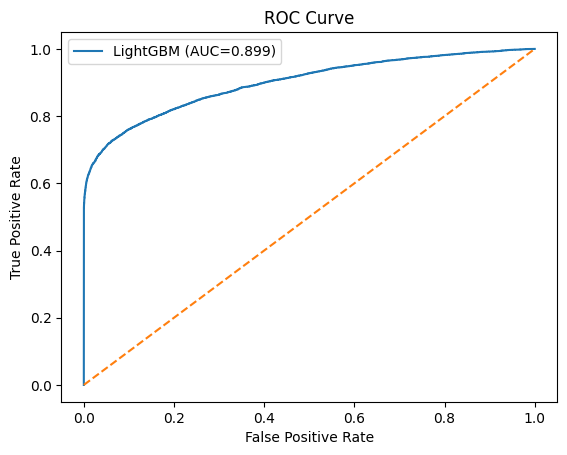

In [57]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob_lgb)

plt.plot(fpr, tpr, label="LightGBM (AUC=0.899)")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [58]:
# Logistic Train AUC
print("Logistic Train AUC:",
      roc_auc_score(y_train, log_model.predict_proba(X_train_scaled)[:,1]))

# Decision Tree Train AUC
print("DT Train AUC:",
      roc_auc_score(y_train, dt_model.predict_proba(X_train)[:,1]))

# XGBoost Train AUC
print("XGB Train AUC:",
      roc_auc_score(y_train, xgb_model.predict_proba(X_train)[:,1]))

# LightGBM Train AUC
print("LGB Train AUC:",
      roc_auc_score(y_train, lgb_model.predict_proba(X_train)[:,1]))

Logistic Train AUC: 0.8513152373000611
DT Train AUC: 0.7747243159219692
XGB Train AUC: 0.9134958254399377
LGB Train AUC: 0.9091062500181408


In [59]:
from sklearn.metrics import roc_auc_score

print("---- OVERFITTING CHECK ----")

# Logistic
train_auc_log = roc_auc_score(y_train, log_model.predict_proba(X_train_scaled)[:,1])
test_auc_log  = roc_auc_score(y_test,  log_model.predict_proba(X_test_scaled)[:,1])
print("\nLogistic")
print("Train AUC:", train_auc_log)
print("Test AUC :", test_auc_log)

# Decision Tree
train_auc_dt = roc_auc_score(y_train, dt_model.predict_proba(X_train)[:,1])
test_auc_dt  = roc_auc_score(y_test,  dt_model.predict_proba(X_test)[:,1])
print("\nDecision Tree")
print("Train AUC:", train_auc_dt)
print("Test AUC :", test_auc_dt)

# XGBoost
train_auc_xgb = roc_auc_score(y_train, xgb_model.predict_proba(X_train)[:,1])
test_auc_xgb  = roc_auc_score(y_test,  xgb_model.predict_proba(X_test)[:,1])
print("\nXGBoost")
print("Train AUC:", train_auc_xgb)
print("Test AUC :", test_auc_xgb)

# LightGBM
train_auc_lgb = roc_auc_score(y_train, lgb_model.predict_proba(X_train)[:,1])
test_auc_lgb  = roc_auc_score(y_test,  lgb_model.predict_proba(X_test)[:,1])
print("\nLightGBM")
print("Train AUC:", train_auc_lgb)
print("Test AUC :", test_auc_lgb)

---- OVERFITTING CHECK ----

Logistic
Train AUC: 0.8513152373000611
Test AUC : 0.8538098102816347

Decision Tree
Train AUC: 0.7747243159219692
Test AUC : 0.7825830619586068

XGBoost
Train AUC: 0.9134958254399377
Test AUC : 0.8988028028401625

LightGBM
Train AUC: 0.9091062500181408
Test AUC : 0.8990543358580652


In [60]:
# Set final model used by recommendation engine
model = lgb_model

In [61]:
def expected_loss_engine(input_data):

    # Step 1: Predict default probability
    prob = float(model.predict_proba(input_data)[0][1])

    # Step 2: Loan exposure
    loan_amount = float(input_data["loan_amount"].values[0])

    # Step 3: Expected Loss
    expected_loss = prob * loan_amount

    # Step 4: Decision logic
    if expected_loss < 50000:
        risk = "Low"
        action = "Send automated reminder"

    elif expected_loss < 200000:
        risk = "Medium"
        action = "Call borrower and discuss repayment plan"

    elif expected_loss < 500000:
        risk = "High"
        action = "Assign dedicated recovery agent"

    else:
        risk = "Critical"
        action = "Escalate to recovery and legal team"

    return {
        "Default Probability": round(prob,4),
        "Expected Loss": round(expected_loss,2),
        "Risk Level": risk,
        "Recommended Action": action
    }

In [62]:
sample_input = X_test.iloc[[0]]

result = expected_loss_engine(sample_input)

print("Default Probability:", result["Default Probability"])
print("Expected Loss: ₹", result["Expected Loss"])
print("Risk Level:", result["Risk Level"])
print("Recommended Action:", result["Recommended Action"])

Default Probability: 0.0341
Expected Loss: ₹ 21367.08
Risk Level: Low
Recommended Action: Send automated reminder


In [63]:
for i in range(10):
    sample = X_test.iloc[[i]]
    print(expected_loss_engine(sample))

{'Default Probability': 0.0341, 'Expected Loss': 21367.08, 'Risk Level': 'Low', 'Recommended Action': 'Send automated reminder'}
{'Default Probability': 0.0521, 'Expected Loss': 13367.6, 'Risk Level': 'Low', 'Recommended Action': 'Send automated reminder'}
{'Default Probability': 0.101, 'Expected Loss': 27937.29, 'Risk Level': 'Low', 'Recommended Action': 'Send automated reminder'}
{'Default Probability': 0.1108, 'Expected Loss': 47238.18, 'Risk Level': 'Low', 'Recommended Action': 'Send automated reminder'}
{'Default Probability': 0.1356, 'Expected Loss': 25282.03, 'Risk Level': 'Low', 'Recommended Action': 'Send automated reminder'}
{'Default Probability': 0.6851, 'Expected Loss': 93514.72, 'Risk Level': 'Medium', 'Recommended Action': 'Call borrower and discuss repayment plan'}
{'Default Probability': 0.0704, 'Expected Loss': 16657.44, 'Risk Level': 'Low', 'Recommended Action': 'Send automated reminder'}
{'Default Probability': 0.1314, 'Expected Loss': 20559.83, 'Risk Level': 'Low',

In [64]:
for i in range(20):

    sample = X_test.iloc[[i]]
    result = expected_loss_engine(sample)

    if result["Risk Level"] == "High":
        print("Borrower Index:", i)
        print(result)
        print("--------------------")

In [65]:
high_risk_count = 0

for i in range(len(X_test)):

    sample = X_test.iloc[[i]]
    result = expected_loss_engine(sample)

    if result["Risk Level"] == "High":
        high_risk_count += 1

print("Total High Risk Borrowers:", high_risk_count)

Total High Risk Borrowers: 2756


In [66]:
high_risk_indices = []

for i in range(len(X_test)):

    sample = X_test.iloc[[i]]
    result = expected_loss_engine(sample)

    if result["Risk Level"] == "High":
        high_risk_indices.append(i)

print("High Risk Borrower Indices:")
print(high_risk_indices[:20])  # first 20 indices

High Risk Borrower Indices:
[33, 43, 78, 81, 88, 104, 120, 125, 135, 140, 141, 172, 186, 217, 229, 230, 231, 242, 247, 283]


In [67]:
for idx in high_risk_indices[:10]:

    borrower = X_test.iloc[[idx]]
    result = expected_loss_engine(borrower)

    print("Borrower Index:", idx)
    print("Default Probability:", result["Default Probability"])
    print("Expected Loss: ₹", result["Expected Loss"])
    print("Risk Level:", result["Risk Level"])
    print("Recommended Action:", result["Recommended Action"])
    print("----------------------------")

Borrower Index: 33
Default Probability: 0.9999
Expected Loss: ₹ 206477.92
Risk Level: High
Recommended Action: Assign dedicated recovery agent
----------------------------
Borrower Index: 43
Default Probability: 0.9999
Expected Loss: ₹ 286465.4
Risk Level: High
Recommended Action: Assign dedicated recovery agent
----------------------------
Borrower Index: 78
Default Probability: 0.7181
Expected Loss: ₹ 205740.28
Risk Level: High
Recommended Action: Assign dedicated recovery agent
----------------------------
Borrower Index: 81
Default Probability: 0.9999
Expected Loss: ₹ 336453.57
Risk Level: High
Recommended Action: Assign dedicated recovery agent
----------------------------
Borrower Index: 88
Default Probability: 0.4723
Expected Loss: ₹ 399781.79
Risk Level: High
Recommended Action: Assign dedicated recovery agent
----------------------------
Borrower Index: 104
Default Probability: 0.9998
Expected Loss: ₹ 236463.82
Risk Level: High
Recommended Action: Assign dedicated recovery age

In [68]:
def batch_recommendations(data):

    results = []

    for i in range(len(data)):
        rec = expected_loss_engine(data.iloc[[i]])
        results.append(rec)

    return results

In [69]:
batch_recommendations(X_test.head(5))

[{'Default Probability': 0.0341,
  'Expected Loss': 21367.08,
  'Risk Level': 'Low',
  'Recommended Action': 'Send automated reminder'},
 {'Default Probability': 0.0521,
  'Expected Loss': 13367.6,
  'Risk Level': 'Low',
  'Recommended Action': 'Send automated reminder'},
 {'Default Probability': 0.101,
  'Expected Loss': 27937.29,
  'Risk Level': 'Low',
  'Recommended Action': 'Send automated reminder'},
 {'Default Probability': 0.1108,
  'Expected Loss': 47238.18,
  'Risk Level': 'Low',
  'Recommended Action': 'Send automated reminder'},
 {'Default Probability': 0.1356,
  'Expected Loss': 25282.03,
  'Risk Level': 'Low',
  'Recommended Action': 'Send automated reminder'}]

In [70]:
def creditpath_recommendation_engine(data):

    results = []

    for idx in range(len(data)):

        borrower = data.iloc[[idx]]

        # Predict probability
        prob = float(final_model.predict_proba(borrower)[0][1])

        # Risk Score
        risk_score = round(prob * 100, 2)

        # Loan exposure
        loan_amount = float(borrower["loan_amount"].values[0])

        # Expected loss
        expected_loss = prob * loan_amount

        # Risk classification
        if expected_loss < 50000:
            risk_level = "Low"
            action = "Send automated reminder"
            team = "Automated Recovery System"

        elif expected_loss < 200000:
            risk_level = "Medium"
            action = "Call borrower and discuss repayment plan"
            team = "Call Center Recovery Team"

        elif expected_loss < 500000:
            risk_level = "High"
            action = "Assign dedicated recovery agent"
            team = "Field Recovery Officer"

        else:
            risk_level = "Critical"
            action = "Escalate to legal recovery"
            team = "Senior Recovery & Legal Team"

        results.append({
            "borrower_index": int(data.index[idx]),
            "risk_score": risk_score,
            "default_probability": round(prob,4),
            "loan_amount": loan_amount,
            "expected_loss": round(expected_loss,2),
            "risk_level": risk_level,
            "assigned_team": team,
            "recommended_action": action
        })

    return pd.DataFrame(results)